In [1]:
import pandas as pd
import constantes as const
import matplotlib.pyplot as plt


In [2]:
from utils.data import DataManager

data_manager = DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X, y = data_manager.get_X_y()
test = data_manager.get_test()
weights = data_manager.get_weights()
X_test, y_test, weights_test = data_manager.get_test_data()


In [ ]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

data_preprocessor = DataPreprocessor()

model = xgb.XGBClassifier(
    random_state=const.RANDOM_STATE,
    n_jobs=12,
    n_estimators=936,
    max_depth=40,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_test)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))


In [ ]:
y_test_proba = full_pipeline.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_threshold).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [ ]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "XGBoost"

In [8]:
from comet_ml import Experiment

experiment = Experiment(
    api_key="tZzHrgZeB2lMeZSSnDvSFUAIV",
    project_name="proyecto-1-taa",
    workspace="xqft",
)

experiment.set_name("XGBoost - RandomSearchCV - optimizado")
experiment.add_tags(["RandomSearchCV", "XGBoost"])


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, xgboost.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/xqft/proyecto-1-taa/93ea981b24934c1cbcfb1c7092c23704



In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
import numpy as np
import sklearn

import importlib
import utils.comet_experiments as comet_exp
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

importlib.reload(hb_metrics)
importlib.reload(comet_exp)

sklearn.set_config(enable_metadata_routing=True)

ams_custom_score = make_scorer(hb_metrics.ams_scorer, greater_is_better=True, needs_proba=False).set_score_request(sample_weight=True)

X_train, X_val, y_train, y_val, weights_train, weights_val = train_test_split(
    X_train, y_train, weights_train, test_size=0.1, random_state=42
)

model = XGBClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=20
).set_fit_request(sample_weight=True,eval_set=True)

param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 20),
    'max_depth': np.arange(3, 15),
    'subsample': np.linspace(0.3, 1, 15),
    'colsample_bytree': np.linspace(0.3, 1, 15)
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=ams_custom_score,
    cv=3,
    verbose=3,
    random_state=42
)


fit_params = {
    'eval_set': [(X_val, y_val)],
    'sample_weight': weights_train,
}

random_search.fit(X_train, y_train, **fit_params)
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntaje:", random_search.best_score_)

sklearn.set_config(enable_metadata_routing=False)


In [17]:
print("Mejores parámetros:", random_search.best_params_)


Mejores parámetros: {'subsample': 0.95, 'max_depth': 11, 'learning_rate': 0.2847368421052632, 'colsample_bytree': 0.75}


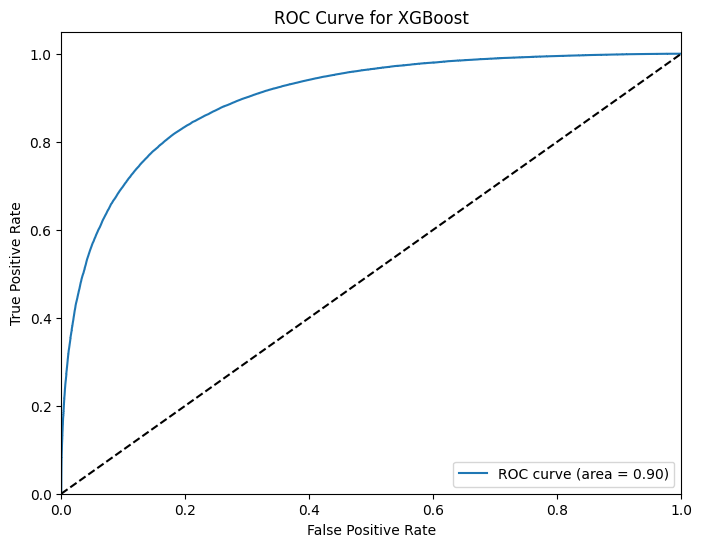

In [8]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, weights_train, weights_val = train_test_split(
    X_train, y_train, weights_train, test_size=0.1, random_state=42
)

data_preprocessor = DataPreprocessor()

model = xgb.XGBClassifier(subsample=0.95, max_depth=11, learning_rate=0.2847368421052632,colsample_bytree=0.75)

full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])


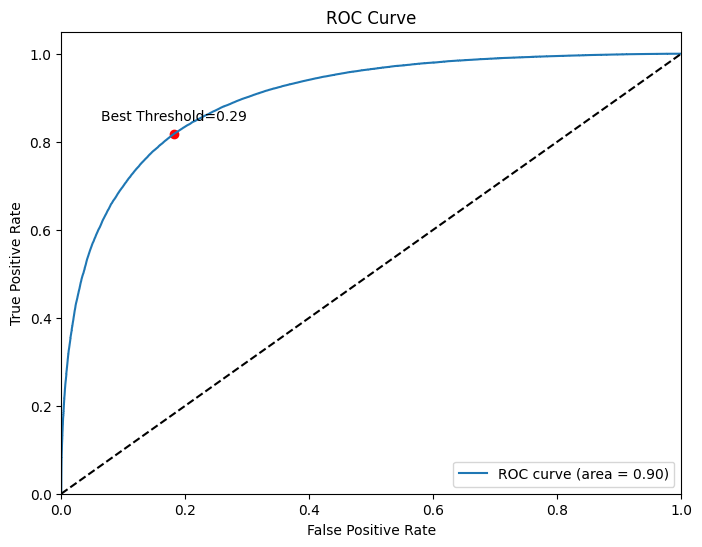

Best Threshold:  0.2882324


In [11]:
y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

J = tpr_forest - fpr_forest
idx = np.argmax(J)
best_thresh = thresholds_forest[idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr_forest[idx], tpr_forest[idx], c='red')  # Marcar el mejor punto
plt.annotate(f'Best Threshold={best_thresh:.2f}', (fpr_forest[idx], tpr_forest[idx]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print("Best Threshold: ", best_thresh)

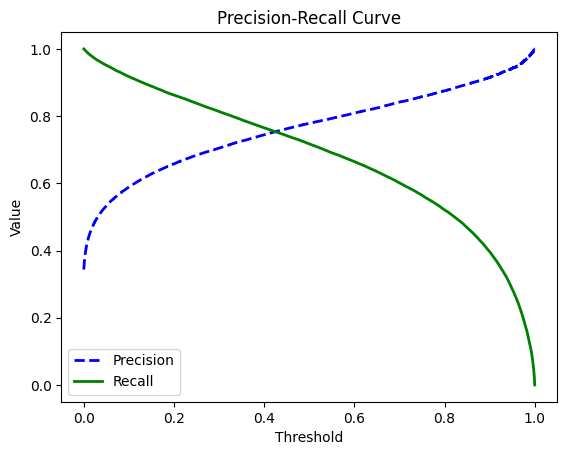

In [4]:
from utils.metrics import MetricsManager as mm 

mm.plot_precision_recall_vs_threshold(y_train, y_scores_forest)

In [12]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_val)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_thresh).astype(int)

print(classification_report(y_val, y_pred_optimal))


              precision    recall  f1-score   support

           0       0.71      0.99      0.83     13186
           1       0.95      0.23      0.37      6814

    accuracy                           0.73     20000
   macro avg       0.83      0.61      0.60     20000
weighted avg       0.79      0.73      0.67     20000



In [13]:
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics
import importlib

hb_metrics.ams_scorer(y_val, y_pred_optimal, weights_val)

signal = 10.033502011257461
background = 134.7242078570069


0.8246616854914859

In [14]:
y_test_proba = full_pipeline.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_thresh).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [15]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "XGBoost 2"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  1%|          | 96.0k/8.81M [00:00<00:09, 973kB/s]
 10%|▉         | 896k/8.81M [00:00<00:01, 5.16MB/s]
 16%|█▌        | 1.38M/8.81M [00:00<00:01, 4.52MB/s]
 26%|██▌       | 2.25M/8.81M [00:00<00:01, 6.19MB/s]
 33%|███▎      | 2.87M/8.81M [00:00<00:02, 3.02MB/s]
 38%|███▊      | 3.31M/8.81M [00:01<00:02, 2.60MB/s]
 42%|████▏     | 3.67M/8.81M [00:01<00:02, 2.46MB/s]
 46%|████▌     | 4.05M/8.81M [00:01<00:01, 2.72MB/s]
 50%|█████     | 4.43M/8.81M [00:01<00:01, 2.98MB/s]
 55%|█████▍    | 4.80M/8.81M [00:01<00:01, 3.17MB/s]
 59%|█████▉    | 5.19M/8.81M [00:01<00:01, 3.36MB/s]
 63%|██████▎   | 5.56M/8.81M [00:01<00:00, 3.51MB/s]
 67%|██████▋   | 5.94M/8.81M [00:01<00:00, 3.60MB/s]
 72%|███████▏  | 6.31M/8.81M [00:01<00:00, 3.69MB/s]
 76%|███████▌  | 6.68M/8.81M [00:02<00:00, 3.72MB/s]
 80%|████████  | 7.05M/8.81M [00:02<00:00, 3.77MB/s]
 84%|████████▍ | 7.43M/8.81M [00:02<00:00, 3.81MB/s]
 89%|████████▊ | 7.80M/8.81M [00:02<00:00, 3.84MB/s]
 93

In [15]:
from utils import data
import importlib

importlib.reload(data)

data_manager = data.DataManager()
data_manager.preparar_conjuntos_ROS()

X_train, y_train, weights_train = data_manager.get_train_data()
X, y = data_manager.get_X_y()
test = data_manager.get_test()
weights = data_manager.get_weights()
X_test, y_test, weights_test = data_manager.get_test_data()

In [28]:
from utils.preprocess import DataPreprocessor
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, weights_train, weights_val = train_test_split(
    X_train, y_train, weights_train, test_size=0.1, random_state=42
)

data_preprocessor = DataPreprocessor()

model = xgb.XGBClassifier(subsample=0.95, max_depth=11, learning_rate=0.2847368421052632,colsample_bytree=0.75)

full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])


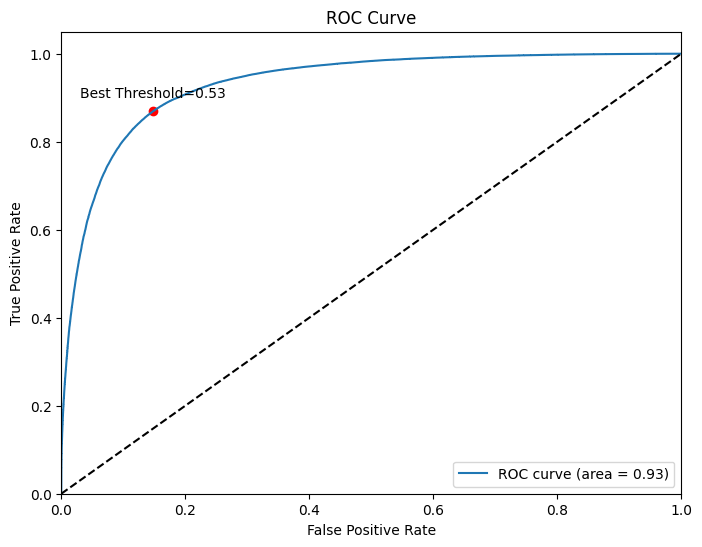

Best Threshold:  0.53477526


In [29]:
y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

J = tpr_forest - fpr_forest
idx = np.argmax(J)
best_thresh = thresholds_forest[idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr_forest[idx], tpr_forest[idx], c='red')  # Marcar el mejor punto
plt.annotate(f'Best Threshold={best_thresh:.2f}', (fpr_forest[idx], tpr_forest[idx]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print("Best Threshold: ", best_thresh)

In [30]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_val)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_thresh).astype(int)

print(classification_report(y_val, y_pred_optimal))


              precision    recall  f1-score   support

           0       0.56      1.00      0.72     13171
           1       0.98      0.22      0.36     13123

    accuracy                           0.61     26294
   macro avg       0.77      0.61      0.54     26294
weighted avg       0.77      0.61      0.54     26294



In [31]:
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

hb_metrics.ams_scorer(y_val, y_pred_optimal, weights_val)

signal = 19.57022012297955
background = 97.48571573298581


1.8343165518949953

In [32]:
y_test_proba = full_pipeline.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_thresh).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [33]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "XGBoost 2"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  1%|          | 104k/8.81M [00:00<00:08, 1.06MB/s]
 10%|█         | 904k/8.81M [00:00<00:01, 5.20MB/s]
 16%|█▌        | 1.38M/8.81M [00:00<00:01, 4.52MB/s]
 26%|██▌       | 2.26M/8.81M [00:00<00:01, 6.18MB/s]
 33%|███▎      | 2.87M/8.81M [00:00<00:02, 3.07MB/s]
 38%|███▊      | 3.31M/8.81M [00:01<00:02, 2.36MB/s]
 42%|████▏     | 3.69M/8.81M [00:01<00:02, 2.61MB/s]
 46%|████▌     | 4.04M/8.81M [00:01<00:01, 2.78MB/s]
 50%|█████     | 4.41M/8.81M [00:01<00:01, 2.99MB/s]
 54%|█████▍    | 4.78M/8.81M [00:01<00:01, 3.20MB/s]
 59%|█████▊    | 5.16M/8.81M [00:01<00:01, 3.38MB/s]
 63%|██████▎   | 5.54M/8.81M [00:01<00:00, 3.51MB/s]
 67%|██████▋   | 5.91M/8.81M [00:01<00:00, 3.62MB/s]
 71%|███████▏  | 6.29M/8.81M [00:01<00:00, 3.68MB/s]
 76%|███████▌  | 6.66M/8.81M [00:02<00:00, 3.74MB/s]
 80%|███████▉  | 7.04M/8.81M [00:02<00:00, 3.68MB/s]
 84%|████████▍ | 7.40M/8.81M [00:02<00:00, 3.64MB/s]
 88%|████████▊ | 7.77M/8.81M [00:02<00:00, 3.72MB/s]
 92

In [4]:
from utils import data
import importlib

importlib.reload(data)

data_manager = data.DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X, y = data_manager.get_X_y()
test = data_manager.get_test()
weights = data_manager.get_weights()
X_val, y_val, weights_val = data_manager.get_test_data()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
import numpy as np
import sklearn

import importlib
import utils.comet_experiments as comet_exp
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

importlib.reload(hb_metrics)
importlib.reload(comet_exp)

sklearn.set_config(enable_metadata_routing=True)

ams_custom_score = make_scorer(hb_metrics.ams_scorer, greater_is_better=True, needs_proba=False).set_score_request(sample_weight=True)


model = XGBClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=20
).set_fit_request(sample_weight=True,eval_set=True)

param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 20),
    'max_depth': np.arange(3, 15),
    'subsample': np.linspace(0.3, 1, 15),
    'colsample_bytree': np.linspace(0.3, 1, 15)
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=ams_custom_score,
    cv=3,
    verbose=3,
    random_state=42
)


fit_params = {
    'eval_set': [(X_val, y_val)],
    'sample_weight': weights_train,
}

random_search.fit(X_train, y_train, **fit_params)
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntaje:", random_search.best_score_)

sklearn.set_config(enable_metadata_routing=False)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
import numpy as np
import sklearn
from sklearn.metrics import log_loss

import importlib
import utils.comet_experiments as comet_exp

importlib.reload(comet_exp)

sklearn.set_config(enable_metadata_routing=True)

log_loss_scorer = make_scorer(log_loss, greater_is_better=False, needs_proba=True)

model = XGBClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
).set_fit_request(sample_weight=True,eval_set=True)

param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 20),
    'max_depth': np.arange(3, 15),
    'subsample': np.linspace(0.3, 1, 15),
    'colsample_bytree': np.linspace(0.3, 1, 15)
}

random_search_log_loss = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=log_loss_scorer,
    cv=3,
    verbose=3,
    random_state=42
)


fit_params = {
    'eval_set': [(X_val, y_val)],
    'sample_weight': weights_train,
}

random_search_log_loss.fit(X_train, y_train, **fit_params)
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntaje:", random_search.best_score_)

sklearn.set_config(enable_metadata_routing=False)

In [8]:
print("Mejores parámetros:", random_search_log_loss.best_params_)
print("Mejor puntaje:", random_search_log_loss.best_score_)

Mejores parámetros: {'subsample': 0.8999999999999999, 'max_depth': 14, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Mejor puntaje: -0.8141390098927888


In [4]:
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntaje:", random_search.best_score_)

Mejores parámetros: {'subsample': 0.95, 'max_depth': 14, 'learning_rate': 0.17789473684210527, 'colsample_bytree': 0.7999999999999999}
Mejor puntaje: 1.5816098356884563


In [5]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from utils.preprocess import DataPreprocessor
from sklearn.model_selection import train_test_split

data_preprocessor = DataPreprocessor()

model = xgb.XGBClassifier(subsample= 0.95, max_depth= 14, learning_rate= 0.17789473684210527, colsample_bytree= 0.7999999999999999)
full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

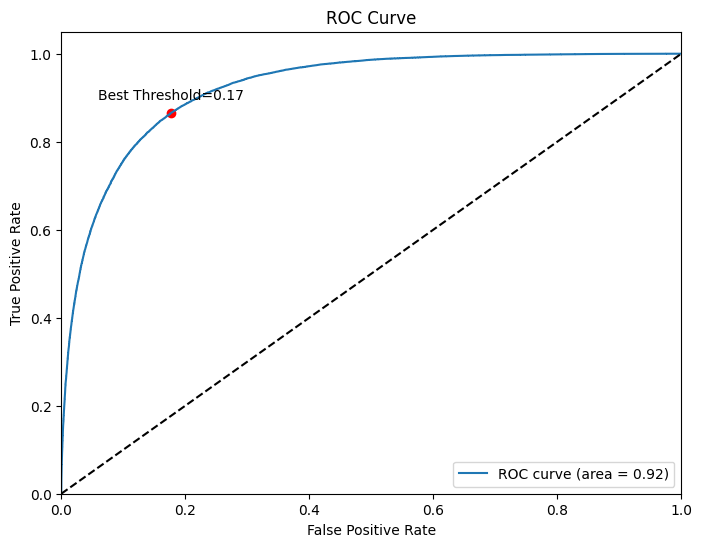

Best Threshold:  0.17434834


In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest, sample_weight=weights_train)

J = tpr_forest - fpr_forest
idx = np.argmax(J)
best_thresh = thresholds_forest[idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr_forest[idx], tpr_forest[idx], c='red')  # Marcar el mejor punto
plt.annotate(f'Best Threshold={best_thresh:.2f}', (fpr_forest[idx], tpr_forest[idx]), textcoords="offset points", xytext=(0,10), ha='center')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

print("Best Threshold: ", best_thresh)


In [8]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from utils.metrics import MetricsManager

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_val)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_scores, sample_weight=weights_val)

y_pred_optimal = (y_scores >= best_thresh).astype(int)

print(classification_report(y_val, y_pred_optimal))


              precision    recall  f1-score   support

           0       0.73      0.99      0.84     33030
           1       0.94      0.28      0.43     16970

    accuracy                           0.75     50000
   macro avg       0.83      0.64      0.64     50000
weighted avg       0.80      0.75      0.70     50000



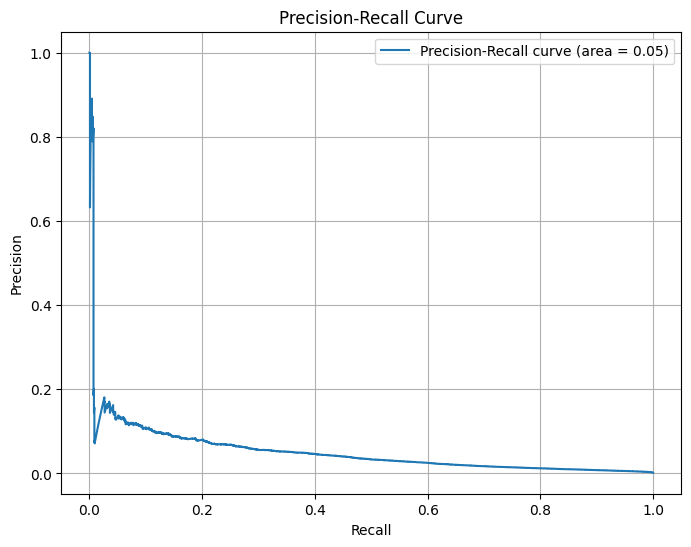

In [9]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, y_scores, sample_weight=weights_val)

auc_score = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (area = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)

plt.show()

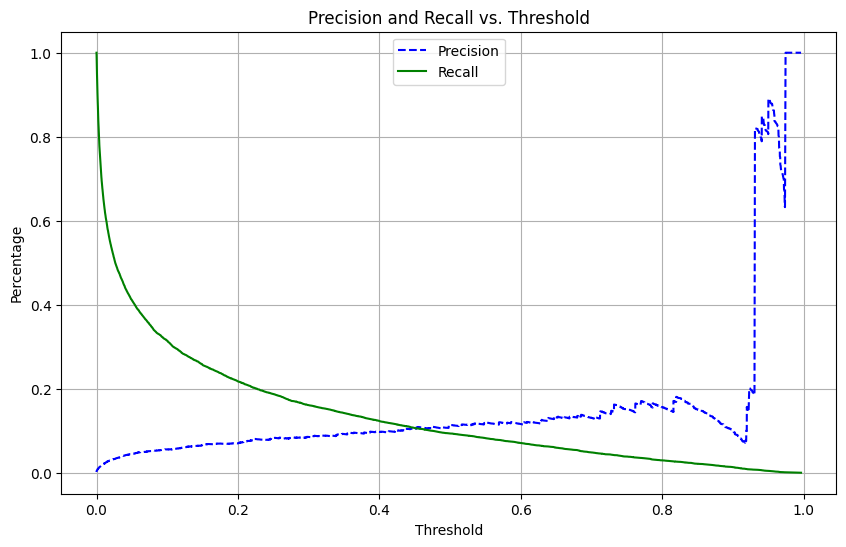

In [10]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, y_scores, sample_weight=weights_val)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision")
plt.plot(thresholds, recall[:-1], "g-", label="Recall")

plt.title("Precision and Recall vs. Threshold")
plt.xlabel("Threshold")
plt.ylabel("Percentage")
plt.legend(loc="best")
plt.grid(True)

plt.show()


In [11]:
import utils.HiggsBosonCompetition_AMSMetric_rev1 as hb_metrics

hb_metrics.ams_scorer(y_val, y_pred_optimal, weights_val)

signal = 32.69440572251986
background = 438.92610742844295


1.5248880369446158

In [12]:
import pandas as pd 

y_test_proba = model.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_thresh).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [13]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "XGBoost sin oversampling AUC"

Successfully submitted to Higgs Boson Machine Learning Challenge



  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  1%|          | 96.0k/8.81M [00:00<00:10, 908kB/s]
 10%|▉         | 880k/8.81M [00:00<00:01, 4.95MB/s]
 15%|█▌        | 1.35M/8.81M [00:00<00:01, 4.44MB/s]
 20%|██        | 1.79M/8.81M [00:00<00:01, 4.25MB/s]
 25%|██▌       | 2.20M/8.81M [00:00<00:03, 2.14MB/s]
 28%|██▊       | 2.51M/8.81M [00:01<00:03, 1.97MB/s]
 33%|███▎      | 2.88M/8.81M [00:01<00:02, 2.33MB/s]
 37%|███▋      | 3.27M/8.81M [00:01<00:02, 2.68MB/s]
 41%|████▏     | 3.65M/8.81M [00:01<00:01, 2.97MB/s]
 46%|████▌     | 4.02M/8.81M [00:01<00:01, 3.20MB/s]
 50%|█████     | 4.41M/8.81M [00:01<00:01, 3.39MB/s]
 54%|█████▍    | 4.78M/8.81M [00:01<00:01, 3.53MB/s]
 59%|█████▊    | 5.16M/8.81M [00:01<00:01, 3.64MB/s]
 63%|██████▎   | 5.53M/8.81M [00:01<00:00, 3.72MB/s]
 67%|██████▋   | 5.91M/8.81M [00:01<00:00, 3.78MB/s]
 71%|███████▏  | 6.28M/8.81M [00:02<00:00, 3.82MB/s]
 76%|███████▌  | 6.66M/8.81M [00:02<00:00, 3.85MB/s]
 80%|███████▉  | 7.03M/8.81M [00:02<00:00, 3.86MB/s]
 84